In [1]:
key_variables_cat = []
no_impact_cat = []

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np
from sklearn.preprocessing import LabelEncoder
from scipy.stats import ks_2samp
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split, GridSearchCV
from xgboost import XGBClassifier
import xgboost as xgb

In [3]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [4]:
train_df.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
train_df.head(2)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,No


In [6]:
train_df.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177263,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [7]:
train_df.isnull().any()

id                  False
gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool

In [8]:
train_df.dtypes

id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

## Categorical Variables

In [9]:
cat_cols = train_df.select_dtypes(["object"])

In [10]:
for col in cat_cols:
    pct = train_df[col].value_counts(normalize=True) * 100
    print(pct.round(2).astype(str))
    print("-"*30)

gender
Female    50.28
Male      49.72
Name: proportion, dtype: object
------------------------------
Partner
Yes    52.1
No     47.9
Name: proportion, dtype: object
------------------------------
Dependents
No     69.74
Yes    30.26
Name: proportion, dtype: object
------------------------------
PhoneService
Yes    93.89
No      6.11
Name: proportion, dtype: object
------------------------------
MultipleLines
No                  47.69
Yes                  46.2
No phone service     6.11
Name: proportion, dtype: object
------------------------------
InternetService
Fiber optic    45.84
DSL            30.48
No             23.68
Name: proportion, dtype: object
------------------------------
OnlineSecurity
No                     48.72
Yes                     27.6
No internet service    23.68
Name: proportion, dtype: object
------------------------------
OnlineBackup
No                     42.09
Yes                    34.23
No internet service    23.68
Name: proportion, dtype: object
-------

In [11]:
def feature_eda(col):
    sns.countplot(x=col, hue='Churn', data=train_df)
    plt.title(f'Churn Distribution by {col}')
    plt.show()

    churn_pct = pd.crosstab(train_df[col], train_df['Churn'], normalize='index') * 100
    display(churn_pct)

    contingency_table = pd.crosstab(train_df[col], train_df['Churn'])

    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    n = contingency_table.values.sum()
    v = np.sqrt(chi2/n * 1)
    print("Cramer's V value:\n")   

    return v

### Gender

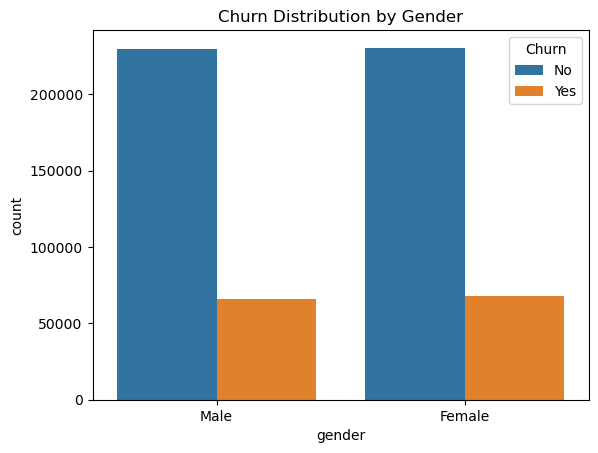

In [12]:
sns.countplot(x='gender', hue='Churn', data=train_df)
plt.title('Churn Distribution by Gender')
plt.show()

In [13]:
churn_pct = pd.crosstab(train_df['gender'], train_df['Churn'], normalize='index') * 100

In [14]:
contingency_table = pd.crosstab(train_df['gender'], train_df['Churn'])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")

Chi-Square Statistic: 27.5111
P-value: 0.0000


Chi-sq is a very large value as N is large. We can calculate Cramer's V instead

In [15]:
n = contingency_table.values.sum()
v = np.sqrt(chi2/n * 1)
print("Cramer's V values:\n")
print(v)

Cramer's V values:

0.006804403408489133


Gender has no impact on the customer churn rate.

In [16]:
no_impact_cat.append("gender")

###  Partner

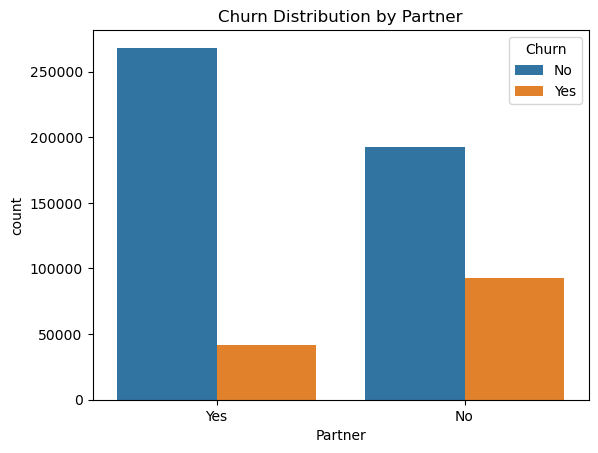

Churn,No,Yes
Partner,,
No,67.537943,32.462057
Yes,86.620428,13.379572


Cramer's V value:



0.22820806427125837

In [17]:
feature_eda("Partner")

Customers with partners churn less than single people

In [18]:
key_variables_cat.append("Partner")

### Dependents

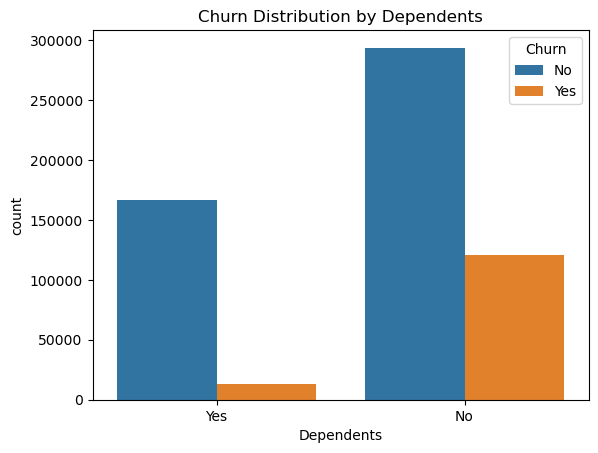

Churn,No,Yes
Dependents,,
No,70.864606,29.135394
Yes,92.720428,7.279572


Cramer's V value:



0.24036443506074728

In [19]:
feature_eda("Dependents")

Customers without dependents churn more

In [20]:
key_variables_cat.append("Dependents")

### PhoneService

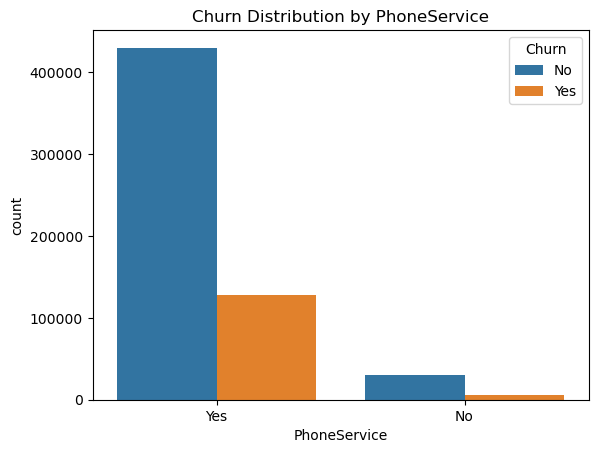

Churn,No,Yes
PhoneService,,
No,83.185036,16.814964
Yes,77.107976,22.892024


Cramer's V value:



0.034834613244285696

In [21]:
feature_eda("PhoneService")

Some difference, but no significant impact of PhoneService on customer churn rate

In [22]:
no_impact_cat.append("PhoneService")

###  MultipleLines

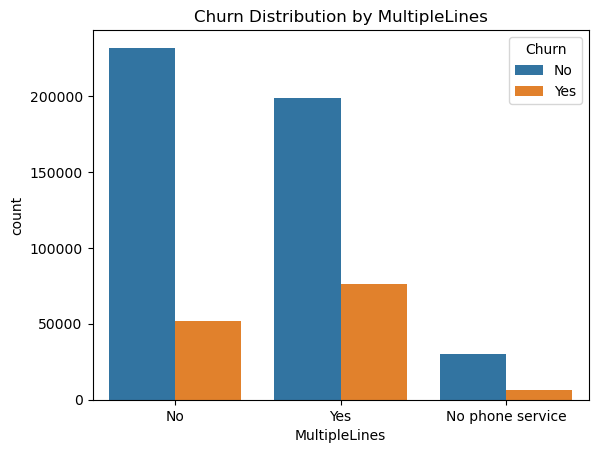

Churn,No,Yes
MultipleLines,,
No,81.767849,18.232151
No phone service,83.185036,16.814964
Yes,72.297447,27.702553


Cramer's V value:



0.11522189807841025

In [23]:
feature_eda("MultipleLines")

Customers with multiple lines churn more 

In [24]:
key_variables_cat.append("MultipleLines")

###  InternetService

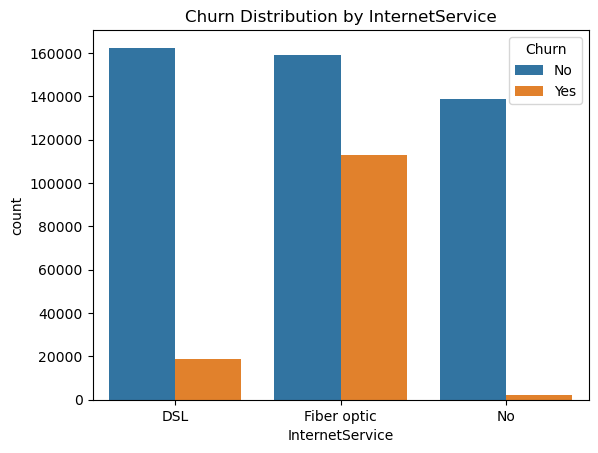

Churn,No,Yes
InternetService,,
DSL,89.693563,10.306437
Fiber optic,58.463357,41.536643
No,98.568860,1.431140


Cramer's V value:



0.42594071590348165

In [25]:
feature_eda("InternetService")

Customers without fiber optic chrun very rarely, and customers with fiber optic churn a lot

In [26]:
key_variables_cat.append("InternetService")

### OnlineSecurity

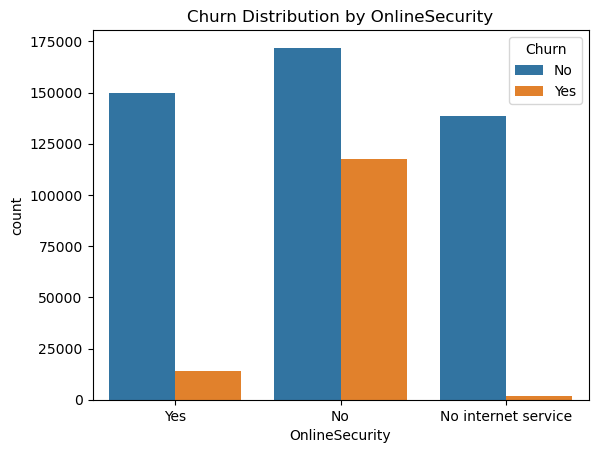

Churn,No,Yes
OnlineSecurity,,
No,59.386681,40.613319
No internet service,98.568860,1.431140
Yes,91.317922,8.682078


Cramer's V value:



0.42667776464649604

In [27]:
feature_eda("OnlineSecurity")

Customers with no online security have a very high churn rate, and customers without internet service have a very high retention rate.

In [28]:
key_variables_cat.append("OnlineSecurity")

### OnlineBackup

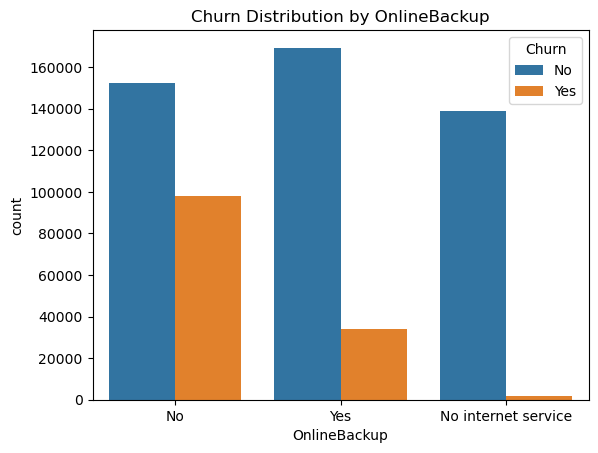

Churn,No,Yes
OnlineBackup,,
No,60.897382,39.102618
No internet service,98.568860,1.431140
Yes,83.275971,16.724029


Cramer's V value:



0.3650788495242065

In [29]:
feature_eda("OnlineBackup")

### DeviceProtection

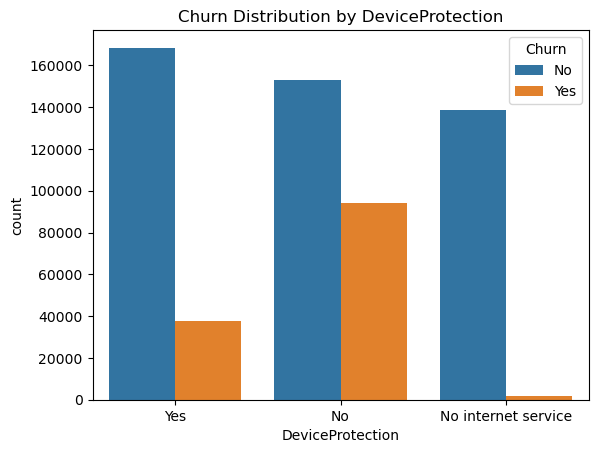

Churn,No,Yes
DeviceProtection,,
No,61.937043,38.062957
No internet service,98.568860,1.431140
Yes,81.734194,18.265806


Cramer's V value:



0.3487169220343249

In [30]:
feature_eda("DeviceProtection")

Customers without device protection have a high churn rate, and customers without internet service have a high retention rate.

In [31]:
key_variables_cat.append("DeviceProtection")

### TechSupport

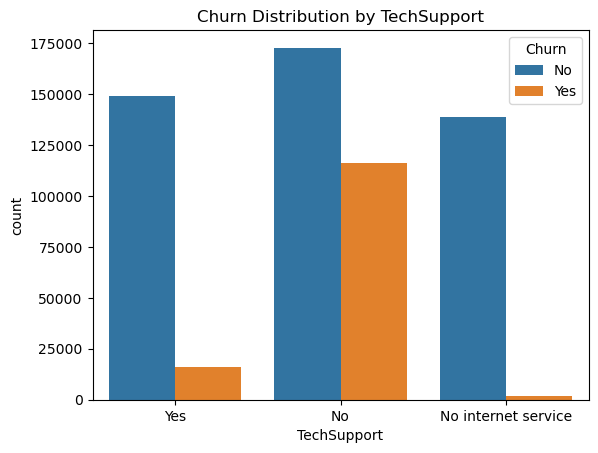

Churn,No,Yes
TechSupport,,
No,59.837960,40.162040
No internet service,98.568860,1.431140
Yes,90.353314,9.646686


Cramer's V value:



0.4163522693068999

In [32]:
feature_eda("TechSupport")

Customers without TechSupport have a high churn rate, and customers without internet service have a high retention rate

In [33]:
key_variables_cat.append("TechSupport")

### StreamingTV

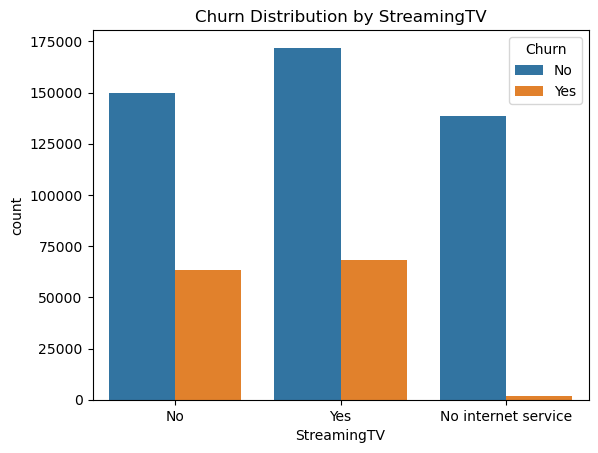

Churn,No,Yes
StreamingTV,,
No,70.258390,29.741610
No internet service,98.568860,1.431140
Yes,71.534034,28.465966


Cramer's V value:



0.281570115378682

In [34]:
feature_eda("StreamingTV")

Customers without internet service have a high retention rate. Customers who answered "yes" and "no" to StreamingTV have a very similar churn rate ~30%

In [35]:
key_variables_cat.append("StreamingTV")

### StreamingMovies

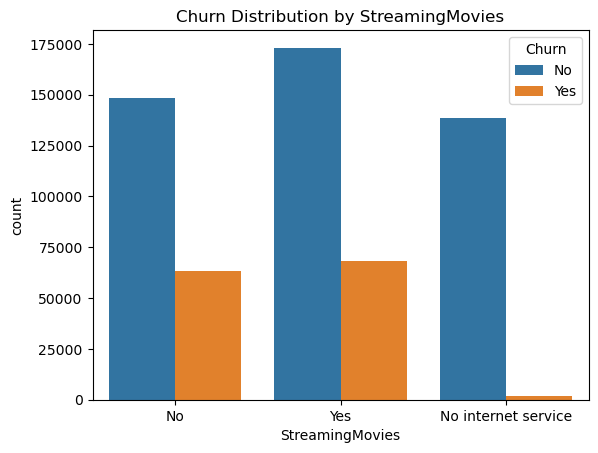

Churn,No,Yes
StreamingMovies,,
No,70.070084,29.929916
No internet service,98.568860,1.431140
Yes,71.693416,28.306584


Cramer's V value:



0.2817647358107614

In [36]:
feature_eda("StreamingMovies")

Customers with no internet service have a high retention rate, and other groups have a similar retention rate of ~30%

In [37]:
key_variables_cat.append("StreamingMovies")

### Contract

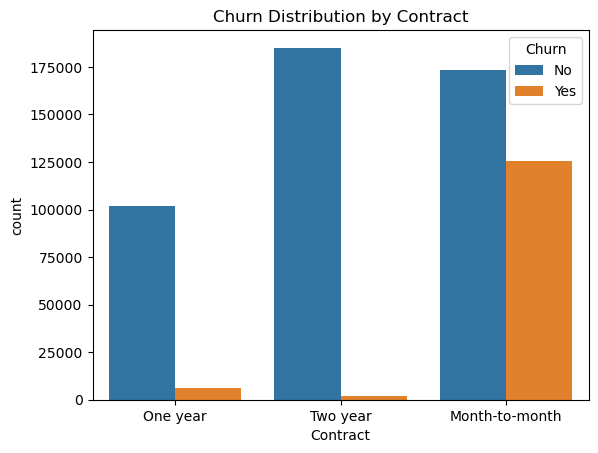

Churn,No,Yes
Contract,,
Month-to-month,57.945657,42.054343
One year,94.237213,5.762787
Two year,99.001835,0.998165


Cramer's V value:



0.4720932942138817

In [38]:
feature_eda("Contract")

The shorter the contract, the higher the churn rate.

In [39]:
key_variables_cat.append("Contract")

### PaperlessBilling

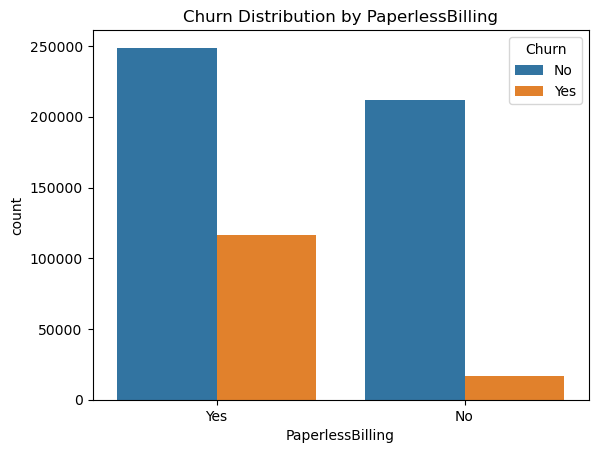

Churn,No,Yes
PaperlessBilling,,
No,92.539422,7.460578
Yes,68.061349,31.938651


Cramer's V value:



0.2851027750439544

In [40]:
feature_eda("PaperlessBilling")

Customers with paper billing have a higher retention rate than customers with paperless billing.

In [41]:
key_variables_cat.append("PaperlessBilling")

### PaymentMethod

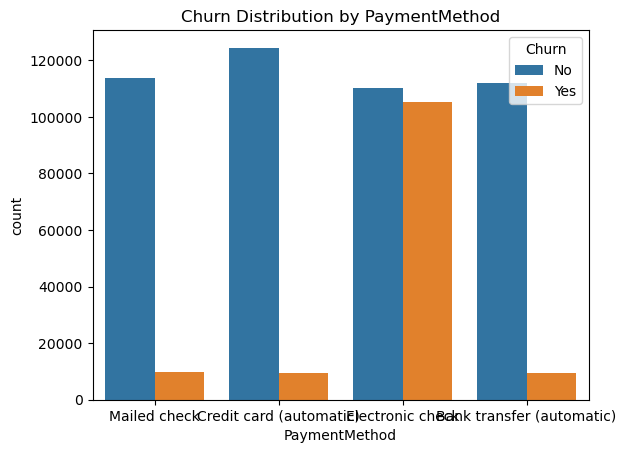

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),92.290705,7.709295
Credit card (automatic),93.066826,6.933174
Electronic check,51.094850,48.905150
Mailed check,92.030350,7.969650


Cramer's V value:



0.4763317492001345

In [42]:
feature_eda("PaymentMethod")

Customers paying with electronic check have a much higher churn rate than other payment methods.

In [43]:
key_variables_cat.append("PaymentMethod")

### SeniorCitizen

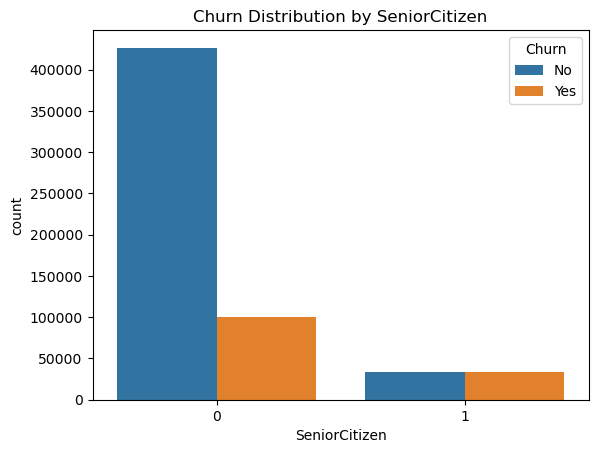

Churn,No,Yes
SeniorCitizen,,
0,81.022616,18.977384
1,49.968289,50.031711


Cramer's V value:



0.23635541373798633

In [44]:
feature_eda("SeniorCitizen")

Senior Citizens churn much more than the rest of the population

In [45]:
key_variables_cat.append("SeniorCitizen")

In [46]:
key_variables_cat

['Partner',
 'Dependents',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'SeniorCitizen']

In [47]:
no_impact_cat

['gender', 'PhoneService']

## Numeric Variables

In [48]:
key_variables_num = []
no_impact_num = []

In [49]:
numeric_cols = train_df.select_dtypes(["number"])
variables = list(numeric_cols)

In [50]:
variables.remove("id")
variables.remove("SeniorCitizen") # this is not continuous

In [51]:
variables

['tenure', 'MonthlyCharges', 'TotalCharges']

In [52]:
def eda_numeric(col):
    plot = sns.kdeplot(train_df[col][train_df["Churn"] == "No"], color = 'r', fill = True)
    plot = sns.kdeplot(train_df[col][train_df["Churn"] == "Yes"], color = 'b', fill = True)
    plot.set_xlabel(col)
    plot.set_ylabel('Frequency')
    plot = plot.legend(['Churn = No', 'Churn = Yes'])
    plt.show()

    churn = train_df[train_df['Churn'] == 'Yes'][col]
    no_churn = train_df[train_df['Churn'] == 'No'][col]

    ks_stat, p_value = ks_2samp(churn, no_churn)

    print(f"K-S Statistic (D): {ks_stat:.4f}")

### tenure

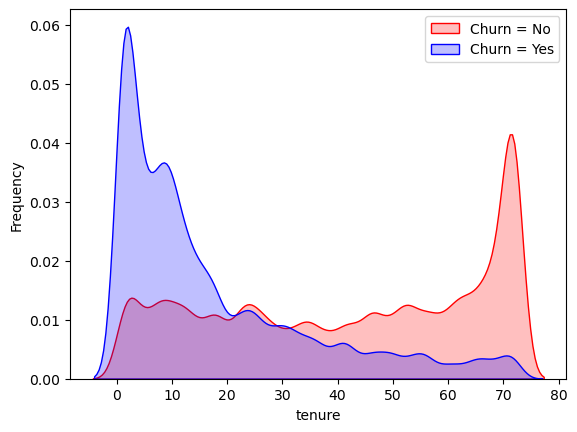

K-S Statistic (D): 0.4509


In [53]:
eda_numeric("tenure")

Longer tenure customers have much greater retention rate

In [54]:
key_variables_num.append("tenure")

### MonthlyCharges

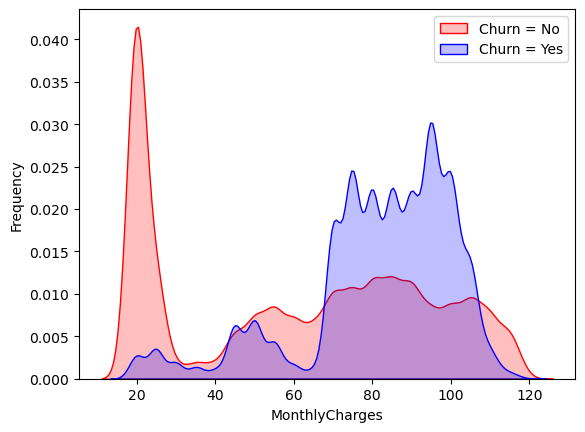

K-S Statistic (D): 0.3725


In [55]:
eda_numeric("MonthlyCharges")

Customers with cheaper monthly charges have better retention than customers with higher monthly charges

In [56]:
key_variables_num.append("MonthlyCharges")

### TotalCharges

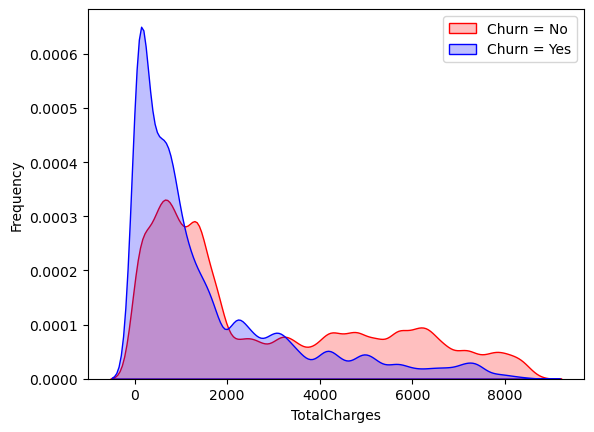

K-S Statistic (D): 0.2475


In [57]:
eda_numeric("TotalCharges")

Customers with cheaper total charges have higher churn rates than customers with more expensive total charges. Intrestingly, this is an opposite trend to the monthly charges variable.


In [58]:
key_variables_num.append("TotalCharges")

## Advanced EDA

In [59]:
original_df = pd.read_csv("original_data.csv")

In [60]:
cat_cols = original_df.select_dtypes(["object"])
cat_cols = list(original_df.columns)

In [61]:
def label_encode_dataframe(df, columns):
    df_encoded = df.copy()
    le = LabelEncoder()
    
    for col in columns:
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        
    return df_encoded

In [62]:
encoded_df = label_encode_dataframe(original_df, cat_cols)
encoded_df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,446,2505,0
1,3962,1,0,0,0,28,1,0,0,2,...,2,0,0,0,1,0,3,802,1466,0


In [63]:
X = encoded_df.drop(["Churn", "customerID"], axis=1)
y = encoded_df["Churn"]

In [64]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify = y, random_state=4)

In [65]:
depths = range(1, 16)
auc_scores = []

for d in depths:
    model = XGBClassifier(max_depth=d)
    scores = cross_val_score(model, X_train, y_train, scoring='roc_auc')
    auc_scores.append(scores.mean())

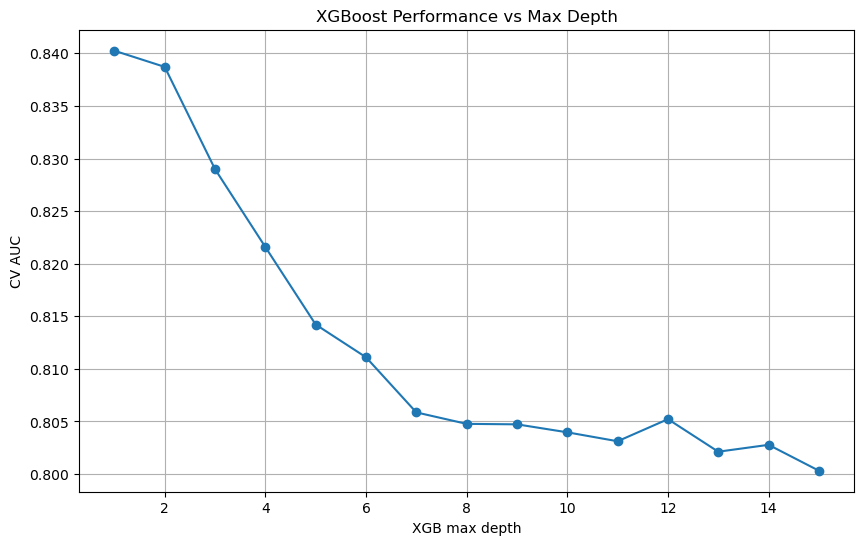

In [66]:
plt.figure(figsize=(10, 6))
plt.plot(depths, auc_scores, marker='o', linestyle='-')
plt.title('XGBoost Performance vs Max Depth')
plt.xlabel('XGB max depth')
plt.ylabel('CV AUC')
plt.grid(True)
plt.show()

Using the original dataset for this kaggle competiton, we find the best AUC when `max_depth` == 1. This is unusual for an XGB model and indicates that the model is acting additively, where each fetaure contributes independentely to the final prediction. 

This is means that:

- Linearity: The relationships between features and the target might be mostly linear

- Feature Independence: The predictive power of the dataset is distributed across individual features rather than combinations of them.

## Ideas

Given the above conclusion, it is not sensible to feed a model complex data and hope it learns the interactions. A more effective approach will likely be to create simple features (e.g. A/B, A x B) instead of complex interactive terms.

My strategy is therefore to start by doing focussing on binning, calculating ratios, target encoding and handling outliers as appropriate. 

I have identified key features in `key_variables_cat` and `key_variables_num`. I will therefore focus my feature engineering on these variables first.

## Artifacts

we can identify artifacts by looking at the difference between the original data and the sythetically created data

In [104]:
original_df = pd.read_csv("original_data.csv")

In [136]:
original_df["TotalCharges"] = pd.to_numeric(original_df["TotalCharges"], errors='coerce').fillna(0)
train_df["TotalCharges"] = pd.to_numeric(train_df["TotalCharges"], errors='coerce').fillna(0)

In [141]:
original_df["total_charges_difference"] = original_df["TotalCharges"] - original_df["MonthlyCharges"] * original_df["tenure"]
original_df["total_charges_difference"].isna().any()

False

<Axes: >

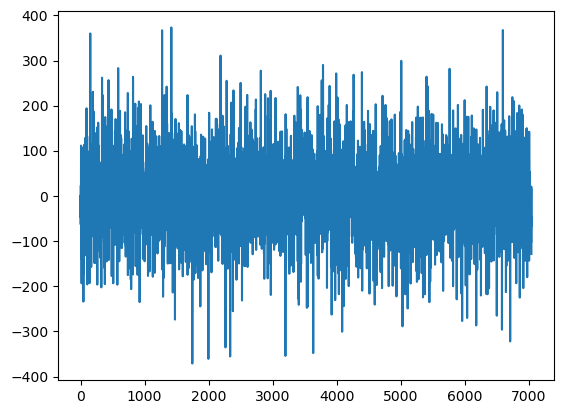

In [142]:
original_df["total_charges_difference"].plot()

In [144]:
train_df["TotalCharges"] = pd.to_numeric(train_df["TotalCharges"], errors='coerce').fillna(0)

train_df["total_charges_difference"] = train_df["TotalCharges"] - train_df["MonthlyCharges"] * train_df["tenure"]
train_df["total_charges_difference"].isna().any()

False

<Axes: >

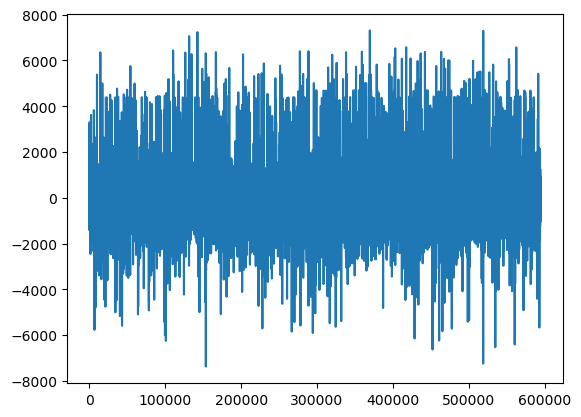

In [145]:
train_df["total_charges_difference"].plot()

In [146]:
train_df

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,total_charges_difference,is_original
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,No,No,One year,Yes,Mailed check,60.10,1653.85,No,-89.05,False
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No,-252.80,False
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No,18.15,False
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes,1.00,False
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes,0.00,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,...,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No,-99.65,False
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No,161.75,False
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No,115.10,False
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,...,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No,95.20,False


In [97]:
comparison_df = pd.concat([
    train_df["total_charges_difference"].describe(),
    original_df["total_charges_difference"].describe()
], axis=1)

comparison_df.columns = ["train_charges_difference", "total_charges_difference"]

comparison_df

,train_charges_difference,total_charges_difference
count,594194.000000,7043.000000
mean,-11.409798,0.152953
std,298.747588,67.202778
min,-7369.250000,-370.850000
25%,-70.550000,-28.600000
50%,0.000000,0.000000
75%,60.250000,28.500000
max,7308.300000,373.250000


Synthetically created data struggles to produce data under the mathematical constraint - total charges = monthly charges * tenure, so this artifact is captured by looking at the difference 

In [99]:
original_df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,total_charges_difference
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.152953
std,0.368612,24.559481,30.090047,2266.794470,67.202778
min,0.000000,0.000000,18.250000,0.000000,-370.850000
25%,0.000000,9.000000,35.500000,398.550000,-28.600000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,28.500000
max,1.000000,72.000000,118.750000,8684.800000,373.250000


In [107]:
train_df.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,total_charges_difference
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057,-11.409798
std,171529.177263,0.317936,25.061922,31.067444,2353.916710,298.747588
min,0.000000,0.000000,1.000000,18.250000,18.800000,-7369.250000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000,-70.550000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000,0.000000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000,60.250000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000,7308.300000


In [115]:
train_df[train_df.duplicated()]

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,total_charges_difference


In [116]:
combined_df = pd.concat([
    train_df,
    original_df
])

In [119]:
combined_df[combined_df.duplicated()] # kaggle data set does not include original data, so they can be combined

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,total_charges_difference,customerID


In [122]:
train_df["is_original"] = False
original_df["is_original"] = True

In [132]:
final_df = pd.concat([
    train_df, 
    original_df.drop("customerID", axis=1)
], axis=0)

In [133]:
final_df

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,total_charges_difference,is_original
0,0.0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,No,No,One year,Yes,Mailed check,60.10,1653.85,No,-89.05,False
1,1.0,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No,-252.80,False
2,2.0,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No,18.15,False
3,3.0,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes,1.00,False
4,4.0,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes,0.00,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,NaN,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,NaN,True
7039,NaN,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,NaN,True
7040,NaN,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,NaN,True
7041,NaN,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,NaN,True


In [129]:
original_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,is_original
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,True
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,True
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,True
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,True
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,True
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,True
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,True
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,True
